In [1]:
import streamlit as st
import json
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

### Gera o json de tema da aplicação

In [88]:
seabornTheme = {'palette':'hls',
    'style': {
        'figure.facecolor': (0,0,0,0),
        'axes.labelcolor': '1',
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.color': '1',
        'ytick.color': '1',
        'axes.axisbelow': True,
        'grid.linestyle': '-',
        'text.color': '1',
        'font.family': ['sans-serif'],
        'font.sans-serif': ['Arial','DejaVu Sans','Liberation Sans','Bitstream Vera Sans','sans-serif'],
        'lines.solid_capstyle': 'round',
        'patch.edgecolor': '0',
        'patch.force_edgecolor': True,
        'image.cmap': 'rocket',
        'xtick.top': False,
        'ytick.right': False,
        'axes.grid': True,
        'axes.facecolor': (0,0,0,0),
        'axes.edgecolor':  (0,0,0,0),
        'grid.color': '1',
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        'axes.spines.right': True,
        'axes.spines.top': True,
        'xtick.bottom': False,
        'ytick.left': False
        },
    'plt_rcParams':{'text.color': "white",
        'axes.labelcolor': "white",
        'figure.facecolor' : (0.0, 0.0, 0.0, 0.0),
        'font.size' : 25,
        'legend.facecolor' : (0.33, 0.33, 0.33, 0.33),
        'legend.fontsize' : 10}}

seabornThemeJson = json.dumps(seabornTheme,indent=4)

with open("Streamlit/seabornTheme.json", "w") as outfile:
    outfile.write(seabornThemeJson)

### Cria uma pequena biblioteca de funções recorrentes para a aplicação

In [18]:
%%writefile Streamlit/ATBiblioteca.py
import streamlit as st
import json
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

def SetPageConfig(title='AT'):
    st.set_page_config(
        #page_title=title,
        layout="wide")

def SetTheme():
    if 'sb_theme' not in st.session_state:
        with open("seabornTheme.json", 'r') as j:
            st.session_state['sb_theme'] = json.load(j)
    sb.set_theme(palette= st.session_state['sb_theme']['palette'],style= st.session_state['sb_theme']['style'])
    plt.rcParams.update(st.session_state['sb_theme']['plt_rcParams'])

def ReadCSV(name,path):
    if name not in st.session_state:
        st.session_state[name] = pd.read_csv(path,engine='pyarrow')
    return st.session_state[name]

def PreserveCSV(name,df):
    if name in st.session_state:
        st.session_state[name] = df
    return st.session_state[name]

def ReadJson(name,path):
    if name not in st.session_state:
        st.session_state[name] = pd.read_json(path)
    return st.session_state[name]

def PreserveJson(name,df):
    if name in st.session_state:
        st.session_state[name] = df
    return st.session_state[name]

def GetBasicTextMarkdown(font_size: float, text: str):
    return f"""<p style='text-align: center; font-size:{font_size}px;'><b>{text}</b></p>"""

Overwriting Streamlit/ATBiblioteca.py


### Cria a capa do trabalho

In [11]:
%%writefile Streamlit/Capa.py
import streamlit as st
import ATBiblioteca as at_lib
from st_pages import Page, show_pages, add_page_title

at_lib.SetPageConfig()

#add_page_title()
show_pages(
    [
        Page('Capa.py','Introdução',":memo:"),
        #Page('Page_0.py','Sobre a aplicação',":building_construction:"),
        Page('Page_1.py','Aquisição de dados',":building_construction:"),
        Page('Page_2.py','Conhecendo a base de dados',":card_file_box:"),
        Page('Page_3.py','Preparação dos dados',":wrench:"),
        Page('Page_5.py','Regressão linear',":bulb:"),
    ]
)


at_lib.SetTheme()

html_p = """<p style='text-align: center; font-size:%spx;'><b>%s</b></p>"""

st.markdown('''<h1 style='text-align: center; '><b>INSTITUTO INFNET</b></h1>''',unsafe_allow_html = True)
st.markdown(html_p % tuple([35,"ESCOLA SUPERIOR DE TECNOLOGIA"]),unsafe_allow_html=True)
st.divider()

github_link = '''https://github.com/Leonidas-Vitor/Steam_Scrapper.git'''
email = '''leonidas.almeida@al.infnet.edu.br'''

columns = st.columns([0.6,0.4])
with columns[0]:
    st.markdown(html_p % tuple([25,'Aluno: Leônidas Almeida']),unsafe_allow_html = True)
    st.markdown(html_p % tuple([25,f'E-mail: <a href= mailto:{email}>{email}</a>']),unsafe_allow_html = True)
    st.markdown(html_p % tuple([25,f'GitHub: <a href={github_link}>Link para o repositório</a><h3>']),unsafe_allow_html = True)
    st.markdown(html_p % tuple([25,'Introdução:']),unsafe_allow_html = True)
    st.text('''
    Esta aplicação foi criada com o propósito de analisar os jogos da loja Steam e então estimar quantas 
    vendas um novo jogo hipotético teria, baseado em suas principais características e então avaliar se 
    vale o investimento nele ou não.
    ''')
    st.text('''
    O modelo de regressão linear foi escolhido por ser um modelo simples e de fácil interpretação, 
    a avaliação do modelo será feita através das métricas de MSE, RMSE e MAE.
    ''')
with columns[1]:
    st.image('Infnet_logo.png',width=400)

#tabs = st.tabs(['Instruções','Observações','Notas do autor'])
#with tabs[0]:
#    st.write('''A aplicação foi organizada em páginas, que podem ser acessadas pela barra lateral à esquerda.''')
#with tabs[1]:
#    st.write('Na última página há um breve registro de dificuldades encontradas na realização do trabalho')
#with tabs[2]:
#    st.markdown('<p> Dá bastante trabalho organizar a estética de uma aplicação web	&#129394;</P>',unsafe_allow_html=True)
#st.divider()


Overwriting Streamlit/Capa.py


### Cria a página que apresenta como a base foi obtida

In [58]:
%%writefile Streamlit/Page_1.py
import ATBiblioteca as at_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import streamlit as st

at_lib.SetPageConfig()
at_lib.SetTheme()

st.header('Obtenção dos de dados',divider=True)

Overwriting Streamlit/Page_1.py


### Apresentação do dataset obtido e situação dele

In [80]:
%%writefile Streamlit/Page_2.py
import ATBiblioteca as at_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import streamlit as st
#import os
#import io

at_lib.SetPageConfig()
at_lib.SetTheme()

st.header('Conhecendo a base de dados',divider=True)

st.warning('''
    Devido ao tamanho original do dataset diversas colunas não relevantes para esse estudo foram 
    removidas e o dataset foi salvo em um novo arquivo que o streamlit permite carregar.
    As colunas removidas foram: short_description, appid, fullgame, hltb_main_extra,
    hltb_completionist, hltb_all_styles, ext_user_account_notice, 
    metacritic, drm_notice, alternate_appid, pc_requirements, 
    platforms, controller_support, demos, hltb_id, hltb_alias
    ''', icon="⚠️")

with st.expander("Colunas do dataset original"):
    markdown = '''
    |Coluna|Descrição|Tipo|
    |------|---------|----|
    |appid|Id de identificação na loja steam|Numérico discreto
    |name|Nome do jogo|Textual
    |scrap_status|Estado do processo de scrap|Textual categórica
    |type|Se é um jogo, demo ou dlc|Categorico
    |steam_appid|Id de identificação na loja steam, o nome da coluna é diferente quando o dado é extraído via API da steam|Numérico discreto
    |required_age|Idade mínima recomendada para o jogo|Numérico discreto
    |is_free|Se é um jogo gratuito|Booleano
    |short_description|Descrição breve do jogo|Textual
    |fullgame|Endereçamento para o jogo completo caso seja uma demo| Dicionário com id e nome do jogo completo
    |supported_languages|Lista de linguas suportadas pelo jogo|Textual
    |pc_requirements|Dicionário dos requisitos para "rodar" o jogo|Textual
    |developers|Nome da desenvolvedora|Textual
    |publishers|Nome da publicadora|Textual
    |platforms|Dicionário relacionando a plataforma e se o jogo está disponível nela|Booleano
    |categories|Dicionário de macro características do jogo|Textual categórica
    |release_date|Dicionário relacionando se o jogo já foi lançada e qual a data de lançamento|Temporal
    |controller_support|Tipo de suporte a controles|Textual categórica
    |positive|Quantidade de avaliações positivas|Numérico discreto
    |negative|Quantidade de avaliações negativas|Numérico discreto
    |tags|Tags do jogo|Textual categórica
    |steamspy_owners|Faixa estimada de proprietários de um jogo|Textual categórica
    |spy_status|Estado do processo de scrap dos dados do SteamSpy|Textual categórica
    |hltb_status|Estado do processo de scrap dos dados do HowLongToBeat|Textual categórica
    |genres|Lista de gêneros do jogo|Textual categórica
    |achievements|Quantidade de conquistas e o nome de algumas delas|Numérico discreta e Textual
    |price_overview|Dicionário contendo os dados de preço e promoções em dólar|Numérico contínuo
    |demos|Endereçamento para a demo caso possua| Dicionário com id e nome da demo
    |hltb_id|Id de identificação no HowLongToBeat|Numérico discreto
    |hltb_name|Nome do jogo no HowLongToBeat|Textual
    |hltb_alias|Apelido do jogo no HowLongToBeat|Textual
    |hltb_similarity|Grau de similaridade entre o nome do jogo buscado e o nome do jogo encontrado no HLTB|Numérico contínuo
    |hltb_main_story|Duração dos objetivos principais do jogo em hrs|Numérico contínuo
    |hltb_main_extra|Duração dos extras do jogo em hrs|Numérico contínuo
    |hltb_completionist|Duração dos objetivos principais, extras e outros em hrs|Numérico contínuo
    |hltb_all_styles|Duração em hrs levando em consideração todos os tipos de jogadores|Numérico contínuo
    |ext_user_account_notice|Desconhecido|Textual
    |recommendations|Quantidade de avaliações do jogo na loja steam|Numérico discreto
    |metacritic|Nota do jogo no site metacritic|Numérico discreto
    |drm_notice|Tipo de DRM do jogo|Textual
    |alternate_appid|Desconhecido|Numérico discreto
    '''

    st.markdown(markdown)


#path_json = os.path.join(os.path.dirname(os.path.realpath(__file__)), "..", "Datasets", "SteamDataset_w_HLTB.json")
#st.text(path_json)

with st.expander("Amostra do dataset original"):
    df_sample = pd.read_csv('SteamDatasetRawSample.csv',engine='pyarrow')
    st.dataframe(df_sample,hide_index=True)

st.subheader('Dataset reduzido')
df_redux = at_lib.ReadCSV('df_redux','SteamDatasetForStreamlit.csv')
st.dataframe(df_redux,hide_index=True,height=250)

#buffer = io.StringIO()
#df_redux.info(buf=buffer)
#s = buffer.getvalue()

st.markdown(at_lib.GetBasicTextMarkdown(20,
    f'''
    O dataset reduzido possui {df_redux.shape[0]} linhas e {df_redux.shape[1]} colunas, sendo que\
    {(df_redux['scrap_status'] != 'Scrap_Sucess').sum()} linhas não possuem dados, indicando um\
    problema de integridade na qualidade de dados. Como não há como recuperar esses dados, eles serão removidos.
    '''),unsafe_allow_html=True)

df_redux.drop(df_redux[df_redux['scrap_status'] != 'Scrap_Sucess'].index,inplace=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Esses são os tipos de cada coluna do dataset nesse momento:
    '''),unsafe_allow_html=True)
    
st.table(df_redux.dtypes)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    É possível observar que muitas colunas são do tipo object e além disso algumas delas são do tipo dicionário, o que\
    dificulta a manipulação dos dados. Na próxima página iremos gerar novas colunas para facilitar a manipulação\
    dos dados além de remover colunas que não serão mais utilizadas.
    '''),unsafe_allow_html=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Vamos observar como está a distribuição dos dados de acordo com o tipo de app.
    '''),unsafe_allow_html=True)

fig, ax = plt.subplots(figsize=(10,5))
sb.histplot(df_redux,x=df_redux['type'], hue=df_redux['type'],ax=ax, alpha=1.0,shrink=0.85)

st.pyplot(fig)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Podemos observar que temos muitas DLCs e demos, além de outros tipos de apps que não são jogos e portanto\
    iremos remove-los também pois não são relevantes para o estudo.
    '''),unsafe_allow_html=True)

df_redux.drop(df_redux[df_redux['type'] != 'game'].index,inplace=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Agora a distribuição das idades recomendadas para os jogos.
    '''),unsafe_allow_html=True)

fig, ax = plt.subplots(figsize=(10,5))
sb.histplot(df_redux,x=df_redux['required_age'], hue=df_redux['required_age'],ax=ax, alpha=1.0,shrink=0.85)

st.pyplot(fig)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    f'''
    Há uma esmadora predominância de idades recomenda 0 anos, algo que é extremamente improvável. Provavelmente\
    esse dado só é crítico de ser colocado na loja para jogos de conteúdo adulto e/ou violento, portanto é muito\
    negligêncido, sendo então um problema confiabilidade desses dados. Infelizmente devido a natureza de publicação\
    da loja Steam não há como buscar dados em quantidade suficiente de outra fonte, portanto não há como utilizar a\
    classificação indicativa nesses estudo.
    '''),unsafe_allow_html=True)

st.divider()
cols = st.columns([0.2,0.3,0.3])
with cols[1]:
    freePercent = (df_redux['is_free'].sum()/df_redux['is_free'].count())*100
    st.metric(label="Jogos gratuitos", value=f'{freePercent:.2f}%')
with cols[2]:
    freePercent = ((df_redux['is_free'].count()-df_redux['is_free'].sum())/df_redux['is_free'].count())*100
    st.metric(label="Jogos pagos", value=f'{freePercent:.2f}%')

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Vamos ver quais desenvolvedores fizeram mais jogos
    '''),unsafe_allow_html=True)
dev_df = df_redux['developers'].value_counts().nlargest(10).reset_index()
dev_df.columns = ['developers','count']
st.table(dev_df)

dev_df = df_redux['developers'].value_counts()

cols = st.columns([0.1,0.2,0.2,0.2])
with cols[1]:
    st.metric(label="Média", value=f'{dev_df.mean():.2f}')
with cols[2]:
    st.metric(label="Mediana", value=f'{dev_df.median()}')
with cols[3]:
    st.metric(label="Desvio Padrão", value=f'{dev_df.std():.2f}')


st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Apesar do top 10 de desenvolvedores terem feito mais de 100 jogos, a média de jogos por desenvolvedor é de\
    apenas 1.65 e a mediana ainda mais baixa de 1 jogo por desenvolvedor, o que indica uma grande oscilação nos dados\
    algo confirmado pela elavado desvio padrão de 13.86.
    '''),unsafe_allow_html=True)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Além disso é bem curioso que tenhamos 3309 de jogos \"Sem\" desenvolvedora, vamos ver quais são esses jogos.
    '''),unsafe_allow_html=True)

st.dataframe(df_redux[df_redux['developers'] == ''])

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Olhando alguns exemplares diretamente na loja steam só é possível inferir que por algum motivo o desenvoveldor\
    preferiu não ser identificado, e não há como saber o motivo.
    '''),unsafe_allow_html=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Agora vamos dar uma olhada nas publicadoras
    '''),unsafe_allow_html=True)
dev_df = df_redux['publishers'].value_counts().nlargest(10).reset_index()
dev_df.columns = ['publishers','count']
st.table(dev_df)

dev_df = df_redux['publishers'].value_counts()

cols = st.columns([0.1,0.2,0.2,0.2])
with cols[1]:
    st.metric(label="Média", value=f'{dev_df.mean():.2f}')
with cols[2]:
    st.metric(label="Mediana", value=f'{dev_df.median()}')
with cols[3]:
    st.metric(label="Desvio Padrão", value=f'{dev_df.std():.2f}')

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Curiosamente tivemos um retrato bem parecido com a dos desenvolvedores, isso deve indicar que há muitas autopublicações\
    na loja Steam. Algo que teremos como confirmar mais a frente quando criamos a coluna self_published.
    '''),unsafe_allow_html=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Agora vamos olhar um pouco para as avaliações dos jogos, afinal uma das premissas para esse estudo é de que\
    há uma boa relação entre quantidade de avaliações e as vendas de um jogo. Para isso foi feito um gráfico de dispersão\
    usando as avaliações positivas e negativas como eixos x e y respectivamente e a quantidade de proprietários como\
    a cor dos pontos.
    '''),unsafe_allow_html=True)

fig, ax = plt.subplots(figsize=(10,5))
sb.scatterplot(df_redux,x='positive', y='negative',hue='steamspy_owners',ax=ax)
#ax.tick_params(axis='x',rotation=45)
ax.ticklabel_format(style='plain', axis='both')
st.pyplot(fig)

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    É possível observar alguns outliers que estão distorcendo a escala do gráfico, contudo, é possível observar que\
    há uma relação entre a quantidade de avaliações positivas e negativas, o que é esperado, afinal quanto mais\
    avaliações positivas um jogo tem, mais avaliações negativas ele tende a ter. Além disso é possível observar que\
    a maioria dos jogos tem poucas avaliações, o que é esperado, afinal a maioria dos jogos não são muito populares.\
    Também é possível observar uma boa correlação entre a quantidade de avaliações e a quantidade de proprietários,\
    o que fortalece a premissa de que há uma boa relação entre a quantidade de avaliações e as vendas de um jogo.
    '''),unsafe_allow_html=True)

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Por fim vamos olhar os dados a respeito de duração dos jogos.
    '''),unsafe_allow_html=True)

fig, ax = plt.subplots(figsize=(10,5))
sb.kdeplot(df_redux[df_redux['hltb_status'] == 'Found'],x=df_redux['hltb_main_story'],ax=ax,fill=True)
st.pyplot(fig)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    É possível observar a presença de algun(s) outliers bem fora da curva, o que está distorcendo muito o gráfico, vamos\
    colocar um limite de 200hrs máxima e refazer o gráfico.
    '''),unsafe_allow_html=True)

fig, ax = plt.subplots(figsize=(10,5))
sb.kdeplot(df_redux[(df_redux['hltb_status'] == 'Found') & (df_redux['hltb_main_story'] < 200) & 
(df_redux['hltb_main_story'] > 0)],
x='hltb_main_story',ax=ax,fill=True)
st.pyplot(fig)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Agora é possível observar que a maioria dos jogos tem uma duração entre 0 e 20 horas.
    '''),unsafe_allow_html=True)

cols = st.columns([0.2,0.3,0.3])
with cols[1]:
    foundPercent = (df_redux[df_redux['hltb_status'] == 'Found']['hltb_status'].count()/df_redux['hltb_status'].count())*100
    st.metric(label="Jogos com dados no HTLB", value=f'{foundPercent:.2f}%')
with cols[2]:
    notFoundPercent = 100-foundPercent
    st.metric(label="Jogos sem dados no HTLB", value=f'{notFoundPercent:.2f}%')

st.markdown(at_lib.GetBasicTextMarkdown(20,
    '''
    Infelizmente a amostra de jogos com dados no HTLB é bem pequena, apenas 37.21% dos jogos possuem dados no HTLB,\
    o que irá nos exigir decidir entre inferir os dados faltantes ou remover os jogos sem dados no HTLB.
    '''),unsafe_allow_html=True)

#for col in df_redux.columns:
#    st.text(df_redux[col].value_counts())

st.divider()

st.markdown(at_lib.GetBasicTextMarkdown(25,
    '''
    Na próxima página iremos preparar os dados para a modelagem.
    '''),unsafe_allow_html=True)
    
st.dataframe(df_redux,hide_index=True,height=250)

st.markdown(at_lib.GetBasicTextMarkdown(20,
    f'''
    O dataset atualmente possui {df_redux.shape[0]} linhas e {df_redux.shape[1]} colunas.
    '''),unsafe_allow_html=True)


Overwriting Streamlit/Page_2.py


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

path = os.getcwd()
path_json = os.path.join(os.getcwd(), "Datasets", "SteamDataset_w_HLTB.json")
print(path_json)
print(os.path.exists(path_json))
df_raw = pd.read_json(path_json)

df_raw.sample(5)

c:\Users\leoni\OneDrive\Documentos\Steam_Scrapper\Datasets\SteamDataset_w_HLTB.json
True


,appid,name,scrap_status,type,steam_appid,required_age,is_free,short_description,fullgame,supported_languages,...,hltb_similarity,hltb_main_story,hltb_main_extra,hltb_completionist,hltb_all_styles,ext_user_account_notice,recommendations,metacritic,drm_notice,alternate_appid
112944,NaN,Turn your Destiny,Scrap_Sucess,game,664080.0,0,0.0,Turn Your Destiny is a new addictive Match-4-o...,NaN,English,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24710,1681780.0,Born Punk Demo,Scrap_NoData,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102681,NaN,Bitcoin,Scrap_Sucess,game,819650.0,0,0.0,Become the new king of cryptocurrency! Bitcoin...,NaN,English<strong>*</strong><br><strong>*</strong...,...,1.0,0.0,0.0,0.83,0.83,NaN,NaN,NaN,NaN,NaN
40435,2018690.0,Far Star Demo,Scrap_NoData,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135612,NaN,HACK_IT,Scrap_Sucess,game,444350.0,0,0.0,HACK_IT presents players with a fully immersiv...,NaN,English<strong>*</strong><br><strong>*</strong...,...,1.0,0.0,0.0,3.00,3.00,NaN,{'total': 133},NaN,NaN,NaN


In [40]:
df_raw[(~df_raw['appid'].isna()) & (df_raw['scrap_status'] != 'Scrap_NoData')]

,appid,name,scrap_status,type,steam_appid,required_age,is_free,short_description,fullgame,supported_languages,...,hltb_similarity,hltb_main_story,hltb_main_extra,hltb_completionist,hltb_all_styles,ext_user_account_notice,recommendations,metacritic,drm_notice,alternate_appid
10557,1863540.0,月出之时,Scrap_Fail <class 'requests.exceptions.JSONDec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71073,1444140.0,Tower!3d Pro - KEWR airport,Scrap_Fail <class 'requests.exceptions.JSONDec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150949,1061400.0,YYDS成神之路,Scrap_Fail <class 'requests.exceptions.JSONDec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173332,2124470.0,活字引擎,Scrap_Fail <class 'requests.exceptions.JSONDec...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_raw[(~df_raw['alternate_appid'].isna())].sample(5)

,appid,name,scrap_status,type,steam_appid,required_age,is_free,short_description,fullgame,supported_languages,...,hltb_similarity,hltb_main_story,hltb_main_extra,hltb_completionist,hltb_all_styles,ext_user_account_notice,recommendations,metacritic,drm_notice,alternate_appid
162632,NaN,Metro: Last Light - RPK,Scrap_Sucess,advertising,222802.0,17,0.0,A deadly Soviet era machine gun with a high ra...,"{'appid': '43160', 'name': 'Uninitialized'}","English<strong>*</strong>, German<strong>*</st...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43160.0
167643,NaN,Family Feud III: Dream Home,Scrap_Sucess,advertising,37940.0,0,0.0,,"{'appid': '37920', 'name': 'Uninitialized'}",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37920.0
169140,NaN,Puzzlegeddon Demo,Scrap_Sucess,advertising,8750.0,0,0.0,,"{'appid': '8740', 'name': 'Uninitialized'}",English,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8740.0
138419,NaN,Stingray,Scrap_Sucess,advertising,405840.0,0,0.0,Autodesk® Stingray is a modern game engine des...,"{'appid': '243580', 'name': 'Uninitialized'}","English, Japanese, Simplified Chinese",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,243580.0
168392,NaN,FINAL FANTASY XI,Scrap_Sucess,advertising,23360.0,0,0.0,,"{'appid': '23390', 'name': 'Uninitialized'}",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23390.0


In [19]:
df_redux = df_raw.drop(columns=['short_description','appid','fullgame','hltb_main_extra',
                     'hltb_completionist','hltb_all_styles','ext_user_account_notice',
                     'metacritic','drm_notice','alternate_appid','pc_requirements',
                     'platforms','controller_support','demos', 'hltb_id','hltb_alias'],inplace=False)

df_redux.sample(5)

,name,scrap_status,type,steam_appid,required_age,is_free,supported_languages,developers,publishers,categories,...,steamspy_owners,spy_status,hltb_status,genres,achievements,price_overview,hltb_name,hltb_similarity,hltb_main_story,recommendations
98676,Trove - Geode Companion Pack 1,Scrap_Sucess,dlc,881590.0,0,0.0,"English<strong>*</strong>, French, German, Por...",[Gamigo US Inc.],[Gamigo US Inc.],"[{'id': 1, 'description': 'Multi-player'}, {'i...",...,NaN,NaN,NaN,"[{'id': '1', 'description': 'Action'}, {'id': ...",NaN,"{'currency': 'USD', 'initial': 1999, 'final': ...",NaN,NaN,NaN,NaN
66052,Topple Tactics Official Soundtrack,Scrap_Sucess,music,2652840.0,0,0.0,English<strong>*</strong><br><strong>*</strong...,[Tim Haywood],[Tewtiy],"[{'id': 2, 'description': 'Single-player'}, {'...",...,NaN,NaN,NaN,"[{'id': '1', 'description': 'Action'}, {'id': ...",NaN,NaN,NaN,NaN,NaN,NaN
155061,The ScreaMaze,Scrap_Sucess,game,1000600.0,0,1.0,English,[White Puppet Studio],[White Puppet Studio],"[{'id': 2, 'description': 'Single-player'}]",...,"0 .. 20,000",Spy_Scrap_Sucess,Not Found,"[{'id': '23', 'description': 'Indie'}]",NaN,NaN,NaN,NaN,NaN,NaN
45674,It Came From Within,Scrap_Sucess,game,1944740.0,0,0.0,English<strong>*</strong><br><strong>*</strong...,[Somewhat Software],[Somewhat Software],"[{'id': 2, 'description': 'Single-player'}]",...,"0 .. 20,000",Spy_Scrap_Sucess,Not Found,"[{'id': '23', 'description': 'Indie'}]",NaN,NaN,NaN,NaN,NaN,NaN
168741,Command & Conquer: Red Alert 3,Scrap_Sucess,game,17480.0,0,0.0,"Czech, English, French, German, Hungarian, Ita...",[EA Los Angeles],[Electronic Arts],"[{'id': 2, 'description': 'Single-player'}]",...,"1,000,000 .. 2,000,000",Spy_Scrap_Sucess,Found,"[{'id': '2', 'description': 'Strategy'}]",NaN,"{'currency': 'USD', 'initial': 1999, 'final': ...",Command & Conquer: Red Alert 3,1.0,21.11,{'total': 11560}


<Axes: >

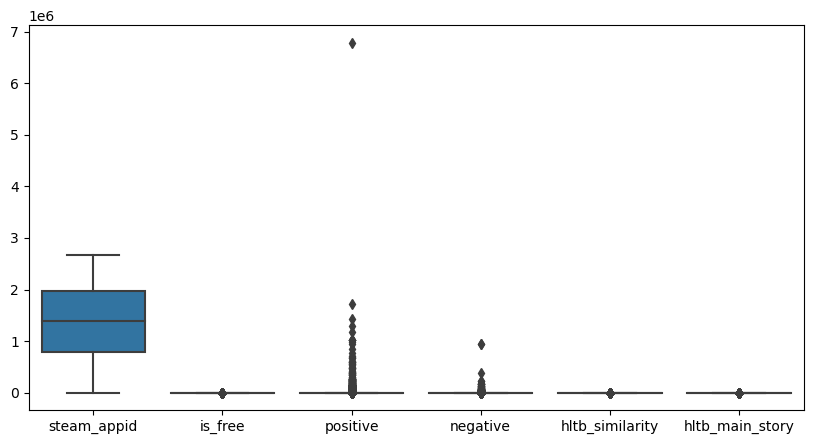

In [20]:
fig, ax = plt.subplots(figsize=(10,5))

sb.boxplot(df_redux,ax=ax)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


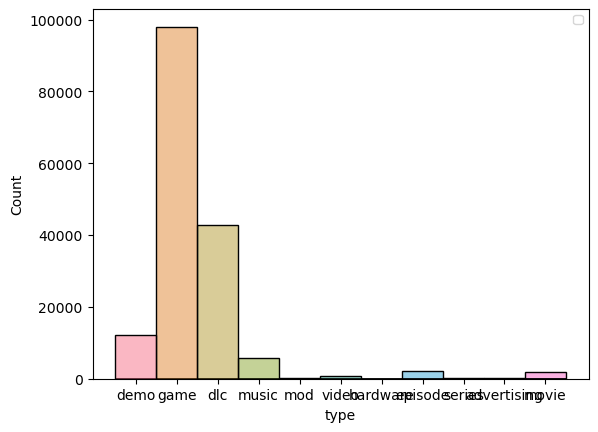

In [43]:
import seaborn as sb

fig, ax = plt.subplots()
sb.histplot(df_redux,x=df_redux['type'],hue=df_redux['type'],ax=ax)
ax.legend(fontsize='small')
plt.show()

In [8]:
(df_redux['scrap_status'] != 'Scrap_Sucess').sum()

15378

In [49]:
df_redux.to_csv('Streamlit/SteamDatasetForStreamlit.csv')

In [48]:
df_redux.columns

Index(['name', 'scrap_status', 'type', 'steam_appid', 'required_age',
       'is_free', 'supported_languages', 'developers', 'publishers',
       'categories', 'release_date', 'positive', 'negative', 'tags',
       'steamspy_owners', 'spy_status', 'hltb_status', 'genres',
       'achievements', 'price_overview', 'hltb_name', 'hltb_similarity',
       'hltb_main_story', 'recommendations'],
      dtype='object')

In [56]:
df_raw.sample(50).to_csv('Streamlit/SteamDatasetRawSample.csv')

Incluir gráficos simples exibindo justamente o dataset como um todo, antes dos filtros, como um histograma de jogos, demos e etc.

### Preparação dos dados (qualidade dos dados)

In [64]:
%%writefile Streamlit/Page_3.py
import ATBiblioteca as at_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import streamlit as st

at_lib.SetPageConfig()
at_lib.SetTheme()

st.header('Preparando os dados',divider=True)

Overwriting Streamlit/Page_3.py


Incluir novos gráficos que demonstrem o estado do dataset e situações problema dos dados

Citar os problema de qualidade encontrados (Aquele primeiro filtro, é na verdade um problema de qualidade de relevância)

Testar passar log em algumas colunas em vez de eliminar outliers

### Alguma página extra se necessário

### Configuração (entrada de dados) + Regressão linear

In [63]:
%%writefile Streamlit/Page_5.py
import ATBiblioteca as at_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import streamlit as st

at_lib.SetPageConfig()
at_lib.SetTheme()

st.header('Regressão linear',divider=True)

Writing Streamlit/Page_5.py
